# Lab 6 â€“ K-Nearest Neighbor and SVM Classification Models
Build K-Nearest Neighbor and SVM classification models and evaluate their performance using appropriate metrics.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

In [2]:
ckd = fetch_ucirepo(id=336)

X = ckd.data.features
y = ckd.data.targets

df = pd.concat([X, y], axis=1)
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [3]:
# Replace '?' with NaN and handle missing values
df.replace('?', np.nan, inplace=True)

num_cols = ['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']
cat_cols = [col for col in df.columns if col not in num_cols + ['class']]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df['class'] = df['class'].str.strip().map({'ckd': 0, 'notckd': 1})

print("Shape:", df.shape)
print("Class distribution:\n", df['class'].value_counts())
df.head()

Shape: (400, 25)
Class distribution:
 class
0    250
1    150
Name: count, dtype: int64


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,3,1,0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,2,0,0,0,0,0
1,7.0,50.0,3,4,0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,1,0,0,0,0,0
2,62.0,80.0,1,2,3,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,2,0,1,0,1,0
3,48.0,70.0,0,4,0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,1,0,1,1,1,0
4,51.0,80.0,1,2,0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,1,0,0,0,0,0


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_feat = df.drop('class', axis=1)
y_target = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y_target, test_size=0.2, random_state=42, stratify=y_target
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Training set:", X_train_sc.shape)
print("Test set:    ", X_test_sc.shape)

Training set: (320, 24)
Test set:     (80, 24)


---
## Part A â€“ K-Nearest Neighbor (KNN)
Classify CKD patients using KNN and find the optimal value of K.

Best K = 3  |  Test Accuracy = 0.9875


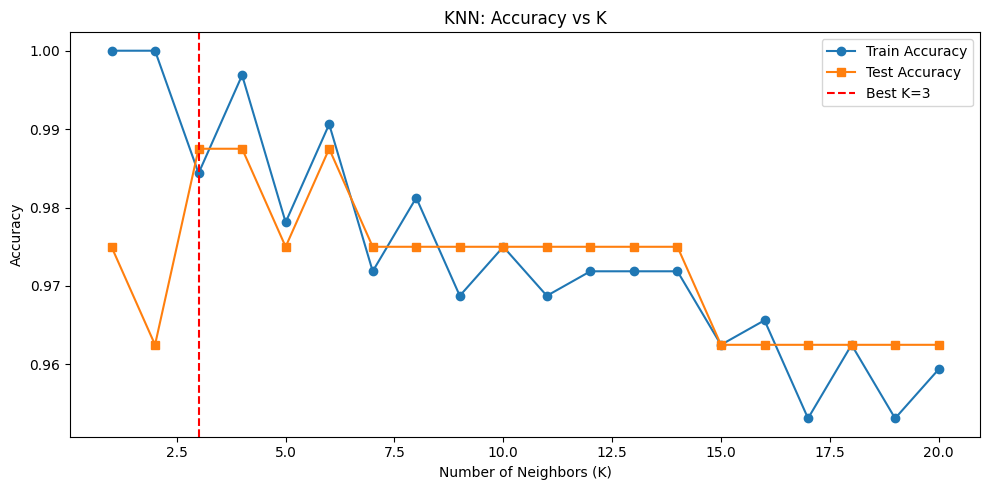

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Find best K
k_values = range(1, 21)
train_acc = []
test_acc  = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sc, y_train)
    train_acc.append(accuracy_score(y_train, knn.predict(X_train_sc)))
    test_acc.append(accuracy_score(y_test, knn.predict(X_test_sc)))

best_k = k_values[np.argmax(test_acc)]
print(f"Best K = {best_k}  |  Test Accuracy = {max(test_acc):.4f}")

plt.figure(figsize=(10, 5))
plt.plot(k_values, train_acc, marker='o', label='Train Accuracy')
plt.plot(k_values, test_acc,  marker='s', label='Test Accuracy')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('KNN: Accuracy vs K')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# Train final KNN model with best K
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_sc, y_train)
y_knn_pred = knn_model.predict(X_test_sc)

### KNN â€“ Evaluation Metrics

In [7]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

print("=== KNN Evaluation Metrics ===")
print(f"Accuracy  : {accuracy_score(y_test, y_knn_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_knn_pred, average='weighted'):.4f}")
print(f"Recall    : {recall_score(y_test, y_knn_pred, average='weighted'):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_knn_pred, average='weighted'):.4f}")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_knn_pred, target_names=['CKD', 'Not CKD']))

=== KNN Evaluation Metrics ===
Accuracy  : 0.9875
Precision : 0.9879
Recall    : 0.9875
F1 Score  : 0.9875

=== Classification Report ===
              precision    recall  f1-score   support

         CKD       1.00      0.98      0.99        50
     Not CKD       0.97      1.00      0.98        30

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



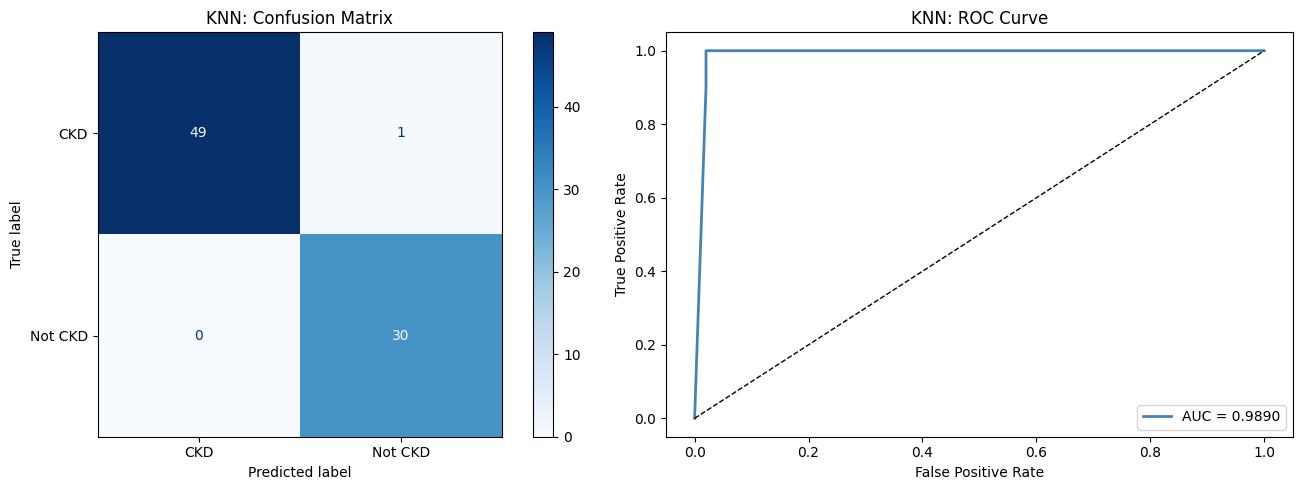

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_knn_pred)
ConfusionMatrixDisplay(cm_knn, display_labels=['CKD', 'Not CKD']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('KNN: Confusion Matrix')

# ROC Curve
y_knn_prob = knn_model.predict_proba(X_test_sc)[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_knn_prob)
roc_auc_knn = auc(fpr_knn, tpr_knn)
axes[1].plot(fpr_knn, tpr_knn, color='steelblue', lw=2, label=f'AUC = {roc_auc_knn:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('KNN: ROC Curve')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

---
## Part B â€“ Support Vector Machine (SVM)
Classify CKD patients using SVM with different kernels.

In [9]:
from sklearn.svm import SVC

kernels = ['linear', 'rbf', 'poly', 'sigmoid']
svm_results = {}

for kernel in kernels:
    svm = SVC(kernel=kernel, probability=True, random_state=42)
    svm.fit(X_train_sc, y_train)
    y_pred = svm.predict(X_test_sc)
    svm_results[kernel] = {
        'model': svm,
        'pred': y_pred,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred, average='weighted')
    }
    print(f"Kernel: {kernel:8s} | Accuracy: {svm_results[kernel]['accuracy']:.4f} | F1: {svm_results[kernel]['f1']:.4f}")

Kernel: linear   | Accuracy: 0.9625 | F1: 0.9624
Kernel: rbf      | Accuracy: 1.0000 | F1: 1.0000
Kernel: poly     | Accuracy: 0.9625 | F1: 0.9626
Kernel: sigmoid  | Accuracy: 0.9750 | F1: 0.9751


In [10]:
# Best SVM kernel
best_kernel = max(svm_results, key=lambda k: svm_results[k]['accuracy'])
print(f"Best kernel: {best_kernel}")

best_svm = svm_results[best_kernel]['model']
y_svm_pred = svm_results[best_kernel]['pred']

print("\n=== SVM Evaluation Metrics ===")
print(f"Accuracy  : {accuracy_score(y_test, y_svm_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_svm_pred, average='weighted'):.4f}")
print(f"Recall    : {recall_score(y_test, y_svm_pred, average='weighted'):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_svm_pred, average='weighted'):.4f}")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_svm_pred, target_names=['CKD', 'Not CKD']))

Best kernel: rbf

=== SVM Evaluation Metrics ===
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

=== Classification Report ===
              precision    recall  f1-score   support

         CKD       1.00      1.00      1.00        50
     Not CKD       1.00      1.00      1.00        30

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



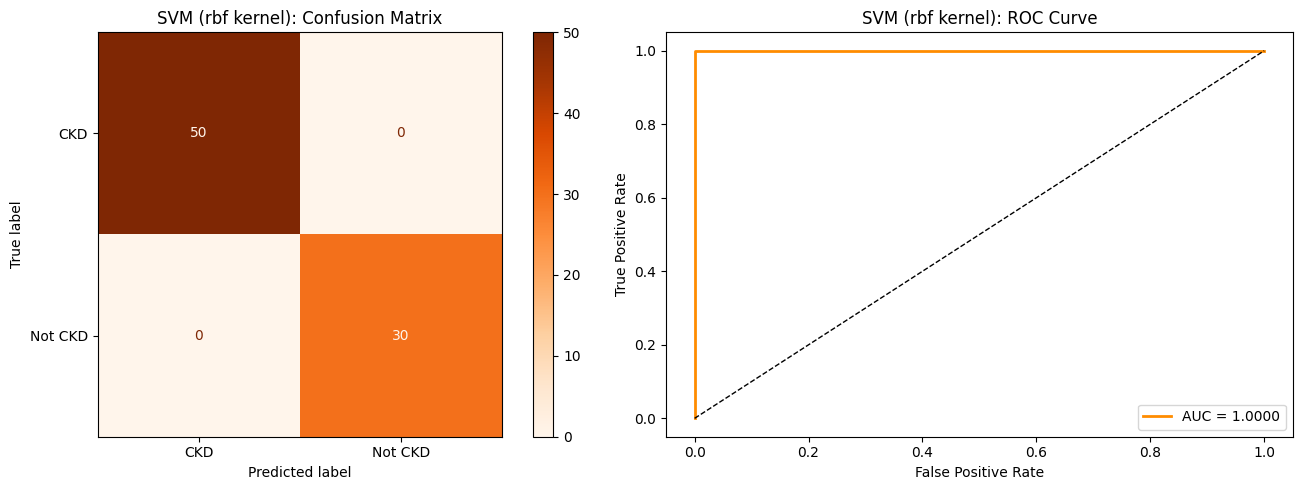

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_svm_pred)
ConfusionMatrixDisplay(cm_svm, display_labels=['CKD', 'Not CKD']).plot(ax=axes[0], cmap='Oranges')
axes[0].set_title(f'SVM ({best_kernel} kernel): Confusion Matrix')

# ROC Curve
y_svm_prob = best_svm.predict_proba(X_test_sc)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_svm_prob)
roc_auc_svm = auc(fpr_svm, tpr_svm)
axes[1].plot(fpr_svm, tpr_svm, color='darkorange', lw=2, label=f'AUC = {roc_auc_svm:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'SVM ({best_kernel} kernel): ROC Curve')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

---
## Model Comparison: KNN vs SVM

           Accuracy  Precision  Recall  F1 Score  ROC AUC
Model                                                    
KNN          0.9875   0.987903  0.9875  0.987539    0.989
SVM (rbf)    1.0000   1.000000  1.0000  1.000000    1.000


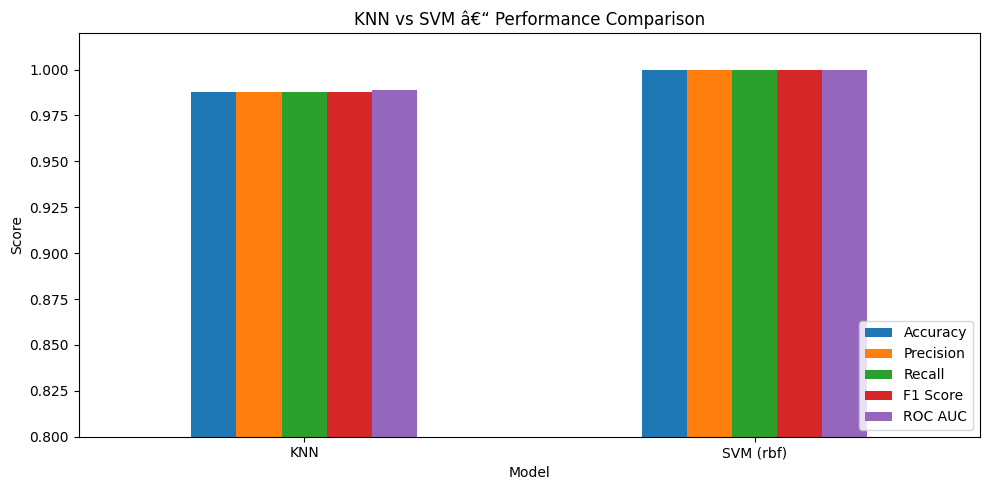

In [12]:
comparison = pd.DataFrame({
    'Model': ['KNN', f'SVM ({best_kernel})'],
    'Accuracy':  [accuracy_score(y_test, y_knn_pred), accuracy_score(y_test, y_svm_pred)],
    'Precision': [precision_score(y_test, y_knn_pred, average='weighted'),
                  precision_score(y_test, y_svm_pred, average='weighted')],
    'Recall':    [recall_score(y_test, y_knn_pred, average='weighted'),
                  recall_score(y_test, y_svm_pred, average='weighted')],
    'F1 Score':  [f1_score(y_test, y_knn_pred, average='weighted'),
                  f1_score(y_test, y_svm_pred, average='weighted')],
    'ROC AUC':   [roc_auc_knn, roc_auc_svm]
})
comparison.set_index('Model', inplace=True)
print(comparison.to_string())

comparison.plot(kind='bar', figsize=(10, 5), ylim=(0.8, 1.02), rot=0)
plt.title('KNN vs SVM â€“ Performance Comparison')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()